<a href="https://colab.research.google.com/github/marycasa20/environmental-satellite-analysis/blob/main/carbon_credit_financial_model_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Financial and Community Benefit Analysis of a Forest Carbon Project

**Modelo financiero de créditos de carbono forestal para Google Colab**

Este notebook estima:
- créditos brutos y comercializables;
- ingresos por venta de créditos;
- costos de inversión y operación;
- distribución de beneficios comunitarios;
- flujo de caja anual;
- VAN, TIR y periodo de recuperación;
- escenarios conservador, base y optimista;
- sensibilidad al precio del carbono y al volumen de créditos.

> **Nota:** todos los datos son ilustrativos y simulados. No representan información real de una empresa o proyecto específico.


In [1]:
# ============================================================
# 1. INSTALACIÓN DE LIBRERÍAS
# ============================================================
!pip -q install numpy-financial


In [2]:
# ============================================================
# 2. IMPORTACIÓN DE LIBRERÍAS
# ============================================================
import numpy as np
import pandas as pd
import numpy_financial as npf
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## 3. Supuestos del proyecto

Modifica los valores de esta sección para construir tus propios escenarios.

In [3]:
# ============================================================
# 3. SUPUESTOS EDITABLES DEL PROYECTO
# ============================================================

project_name = 'Proyecto Forestal Amazónico - Caso Ilustrativo'
project_years = 20
project_area_ha = 50_000

# Generación de créditos
credits_per_ha_year = 2.5       # tCO2e por hectárea por año
buffer_rate = 0.15              # porcentaje retenido por riesgo de permanencia
issuance_success_rate = 0.95    # porcentaje finalmente emitido y vendible

# Precio
initial_carbon_price = 12.0      # USD por tCO2e
annual_price_growth = 0.03       # crecimiento anual del precio

# Distribución de beneficios
community_share = 0.30           # porcentaje del ingreso bruto para comunidades
conservation_fund_share = 0.05   # porcentaje para fondo de conservación

# Inversión y costos
initial_investment = 500_000     # USD en año 0
annual_monitoring_cost = 120_000
annual_admin_cost = 80_000
verification_cost = 150_000
verification_frequency = 3       # cada cuántos años se verifica
sales_fee_rate = 0.05            # comisión sobre ventas
annual_cost_inflation = 0.025

# Evaluación financiera
discount_rate = 0.10

# Crecimiento o degradación del volumen de créditos
annual_credit_change = -0.01     # -1% anual por maduración o menor adicionalidad

print('Proyecto:', project_name)
print('Horizonte:', project_years, 'años')
print('Área:', f'{project_area_ha:,.0f}', 'ha')


Proyecto: Proyecto Forestal Amazónico - Caso Ilustrativo
Horizonte: 20 años
Área: 50,000 ha


In [4]:
# ============================================================
# 4. FUNCIONES FINANCIERAS
# ============================================================

def calculate_npv(rate, cash_flows):
    """Calcula el Valor Actual Neto incluyendo el flujo del año 0."""
    return npf.npv(rate, cash_flows)


def calculate_irr(cash_flows):
    """Calcula la Tasa Interna de Retorno."""
    return npf.irr(cash_flows)


def calculate_payback(cash_flows):
    """Calcula el periodo simple de recuperación con interpolación."""
    cumulative = 0
    for year, cash_flow in enumerate(cash_flows):
        previous = cumulative
        cumulative += cash_flow
        if cumulative >= 0:
            if year == 0:
                return 0.0
            if cash_flow == 0:
                return float(year)
            fraction = abs(previous) / cash_flow
            return (year - 1) + fraction
    return np.nan


def build_carbon_model(
    years,
    area_ha,
    credits_per_ha,
    carbon_price,
    price_growth,
    buffer,
    issuance_rate,
    community_rate,
    conservation_rate,
    initial_capex,
    monitoring_cost,
    admin_cost,
    verification_cost_value,
    verification_every,
    sales_fee,
    cost_inflation,
    credit_change
):
    """Construye el flujo financiero anual del proyecto."""

    rows = []

    # Año 0
    rows.append({
        'Year': 0,
        'Carbon Price (USD/tCO2e)': 0,
        'Gross Credits': 0,
        'Buffer Credits': 0,
        'Saleable Credits': 0,
        'Gross Revenue': 0,
        'Community Benefit': 0,
        'Conservation Fund': 0,
        'Sales Fees': 0,
        'Monitoring Cost': 0,
        'Administrative Cost': 0,
        'Verification Cost': 0,
        'Initial Investment': initial_capex,
        'Total Costs': initial_capex,
        'Net Cash Flow': -initial_capex
    })

    for year in range(1, years + 1):
        price = carbon_price * ((1 + price_growth) ** (year - 1))
        annual_credits_per_ha = credits_per_ha * ((1 + credit_change) ** (year - 1))

        gross_credits = area_ha * annual_credits_per_ha
        buffer_credits = gross_credits * buffer
        saleable_credits = (gross_credits - buffer_credits) * issuance_rate

        gross_revenue = saleable_credits * price
        community_benefit = gross_revenue * community_rate
        conservation_fund = gross_revenue * conservation_rate
        sales_fees = gross_revenue * sales_fee

        monitoring = monitoring_cost * ((1 + cost_inflation) ** (year - 1))
        administration = admin_cost * ((1 + cost_inflation) ** (year - 1))

        verification = 0
        if year == 1 or year % verification_every == 0:
            verification = verification_cost_value * ((1 + cost_inflation) ** (year - 1))

        total_costs = (
            community_benefit
            + conservation_fund
            + sales_fees
            + monitoring
            + administration
            + verification
        )

        net_cash_flow = gross_revenue - total_costs

        rows.append({
            'Year': year,
            'Carbon Price (USD/tCO2e)': price,
            'Gross Credits': gross_credits,
            'Buffer Credits': buffer_credits,
            'Saleable Credits': saleable_credits,
            'Gross Revenue': gross_revenue,
            'Community Benefit': community_benefit,
            'Conservation Fund': conservation_fund,
            'Sales Fees': sales_fees,
            'Monitoring Cost': monitoring,
            'Administrative Cost': administration,
            'Verification Cost': verification,
            'Initial Investment': 0,
            'Total Costs': total_costs,
            'Net Cash Flow': net_cash_flow
        })

    df = pd.DataFrame(rows)
    df['Cumulative Cash Flow'] = df['Net Cash Flow'].cumsum()
    df['Discount Factor'] = 1 / ((1 + discount_rate) ** df['Year'])
    df['Discounted Cash Flow'] = df['Net Cash Flow'] * df['Discount Factor']
    df['Cumulative Discounted Cash Flow'] = df['Discounted Cash Flow'].cumsum()

    return df


In [5]:
# ============================================================
# 5. EJECUCIÓN DEL MODELO BASE
# ============================================================

base_model = build_carbon_model(
    years=project_years,
    area_ha=project_area_ha,
    credits_per_ha=credits_per_ha_year,
    carbon_price=initial_carbon_price,
    price_growth=annual_price_growth,
    buffer=buffer_rate,
    issuance_rate=issuance_success_rate,
    community_rate=community_share,
    conservation_rate=conservation_fund_share,
    initial_capex=initial_investment,
    monitoring_cost=annual_monitoring_cost,
    admin_cost=annual_admin_cost,
    verification_cost_value=verification_cost,
    verification_every=verification_frequency,
    sales_fee=sales_fee_rate,
    cost_inflation=annual_cost_inflation,
    credit_change=annual_credit_change
)

base_model.head(10)


,Year,Carbon Price (USD/tCO2e),Gross Credits,Buffer Credits,Saleable Credits,Gross Revenue,Community Benefit,Conservation Fund,Sales Fees,Monitoring Cost,Administrative Cost,Verification Cost,Initial Investment,Total Costs,Net Cash Flow,Cumulative Cash Flow,Discount Factor,Discounted Cash Flow,Cumulative Discounted Cash Flow
0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,500000,"500,000.00","-500,000.00","-500,000.00",1.00,"-500,000.00","-500,000.00"
1,1,12.00,"125,000.00","18,750.00","100,937.50","1,211,250.00","363,375.00","60,562.50","60,562.50","120,000.00","80,000.00","150,000.00",0,"834,500.00","376,750.00","-123,250.00",0.91,"342,500.00","-157,500.00"
2,2,12.36,"123,750.00","18,562.50","99,928.12","1,235,111.62","370,533.49","61,755.58","61,755.58","123,000.00","82,000.00",0.00,0,"699,044.65","536,066.98","412,816.98",0.83,"443,030.56","285,530.56"
3,3,12.73,"122,512.50","18,376.88","98,928.84","1,259,443.32","377,833.00","62,972.17","62,972.17","126,075.00","84,050.00","157,593.75",0,"871,496.08","387,947.24","800,764.22",0.75,"291,470.51","577,001.06"
4,4,13.11,"121,287.38","18,193.11","97,939.56","1,284,254.36","385,276.31","64,212.72","64,212.72","129,226.87","86,151.25",0.00,0,"729,079.87","555,174.49","1,355,938.71",0.68,"379,191.65","956,192.71"
5,5,13.51,"120,074.50","18,011.18","96,960.16","1,309,554.17","392,866.25","65,477.71","65,477.71","132,457.55","88,305.03",0.00,0,"744,584.25","564,969.92","1,920,908.63",0.62,"350,801.87","1,306,994.58"
6,6,13.91,"118,873.76","17,831.06","95,990.56","1,335,352.39","400,605.72","66,767.62","66,767.62","135,768.99","90,512.66","169,711.23",0,"930,133.83","405,218.56","2,326,127.19",0.56,"228,735.31","1,535,729.89"
7,7,14.33,"117,685.02","17,652.75","95,030.65","1,361,658.83","408,497.65","68,082.94","68,082.94","139,163.21","92,775.47",0.00,0,"776,602.21","585,056.61","2,911,183.80",0.51,"300,226.55","1,835,956.44"
8,8,14.76,"116,508.17","17,476.23","94,080.35","1,388,483.51","416,545.05","69,424.18","69,424.18","142,642.29","95,094.86",0.00,0,"793,130.55","595,352.95","3,506,536.75",0.47,"277,736.55","2,113,692.99"
9,9,15.20,"115,343.09","17,301.46","93,139.54","1,415,836.63","424,750.99","70,791.83","70,791.83","146,208.35","97,472.23","182,760.43",0,"992,775.67","423,060.96","3,929,597.72",0.42,"179,419.15","2,293,112.14"


In [6]:
# ============================================================
# 6. INDICADORES FINANCIEROS
# ============================================================

cash_flows = base_model['Net Cash Flow'].to_numpy()

npv_value = calculate_npv(discount_rate, cash_flows)
irr_value = calculate_irr(cash_flows)
payback_value = calculate_payback(cash_flows)

total_saleable_credits = base_model['Saleable Credits'].sum()
total_revenue = base_model['Gross Revenue'].sum()
total_community_benefit = base_model['Community Benefit'].sum()
total_conservation_fund = base_model['Conservation Fund'].sum()
total_costs = base_model['Total Costs'].sum()
net_profit = base_model['Net Cash Flow'].sum()

cost_per_credit = total_costs / total_saleable_credits
average_revenue_per_credit = total_revenue / total_saleable_credits

summary = pd.DataFrame({
    'Indicator': [
        'NPV',
        'IRR',
        'Simple Payback Period',
        'Total Saleable Credits',
        'Total Gross Revenue',
        'Total Community Benefit',
        'Total Conservation Fund',
        'Total Costs',
        'Net Project Cash Flow',
        'Average Cost per Credit',
        'Average Revenue per Credit'
    ],
    'Value': [
        npv_value,
        irr_value,
        payback_value,
        total_saleable_credits,
        total_revenue,
        total_community_benefit,
        total_conservation_fund,
        total_costs,
        net_profit,
        cost_per_credit,
        average_revenue_per_credit
    ],
    'Unit': [
        'USD',
        '%',
        'Years',
        'tCO2e',
        'USD',
        'USD',
        'USD',
        'USD',
        'USD',
        'USD/tCO2e',
        'USD/tCO2e'
    ]
})

summary.loc[summary['Indicator'] == 'IRR', 'Value'] = irr_value * 100
summary


,Indicator,Value,Unit
0,NPV,"3,963,413.16",USD
1,IRR,88.45,%
2,Simple Payback Period,1.23,Years
3,Total Saleable Credits,"1,838,001.85",tCO2e
4,Total Gross Revenue,"29,342,433.42",USD
5,Total Community Benefit,"8,802,730.03",USD
6,Total Conservation Fund,"1,467,121.67",USD
7,Total Costs,"18,642,972.12",USD
8,Net Project Cash Flow,"10,699,461.30",USD
9,Average Cost per Credit,10.14,USD/tCO2e


In [7]:
# ============================================================
# 7. RESUMEN EN PANTALLA
# ============================================================

print('=' * 65)
print(project_name.upper())
print('=' * 65)
print(f'VAN a {discount_rate:.0%}: USD {npv_value:,.2f}')
print(f'TIR: {irr_value:.2%}')

if np.isnan(payback_value):
    print('Payback: no se recupera dentro del horizonte analizado')
else:
    print(f'Payback simple: {payback_value:.2f} años')

print(f'Créditos comercializables: {total_saleable_credits:,.0f} tCO2e')
print(f'Ingresos brutos: USD {total_revenue:,.2f}')
print(f'Beneficios comunitarios: USD {total_community_benefit:,.2f}')
print(f'Fondo de conservación: USD {total_conservation_fund:,.2f}')
print(f'Costo promedio por crédito: USD {cost_per_credit:,.2f}/tCO2e')
print('=' * 65)


PROYECTO FORESTAL AMAZÓNICO - CASO ILUSTRATIVO
VAN a 10%: USD 3,963,413.16
TIR: 88.45%
Payback simple: 1.23 años
Créditos comercializables: 1,838,002 tCO2e
Ingresos brutos: USD 29,342,433.42
Beneficios comunitarios: USD 8,802,730.03
Fondo de conservación: USD 1,467,121.67
Costo promedio por crédito: USD 10.14/tCO2e


## 8. Gráficos financieros

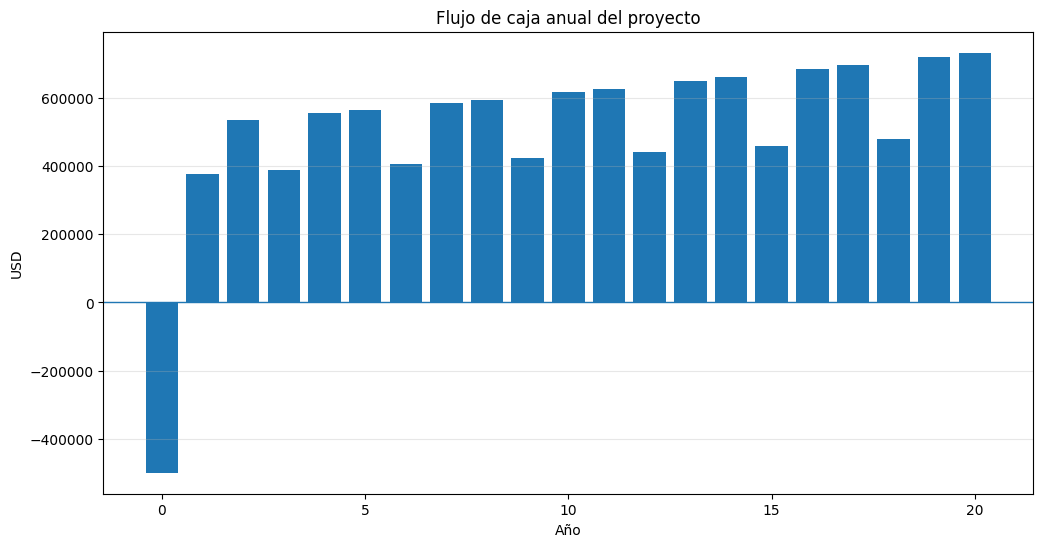

In [8]:
# Flujo de caja anual
plt.figure(figsize=(12, 6))
plt.bar(base_model['Year'], base_model['Net Cash Flow'])
plt.axhline(0, linewidth=1)
plt.title('Flujo de caja anual del proyecto')
plt.xlabel('Año')
plt.ylabel('USD')
plt.grid(axis='y', alpha=0.3)
plt.show()


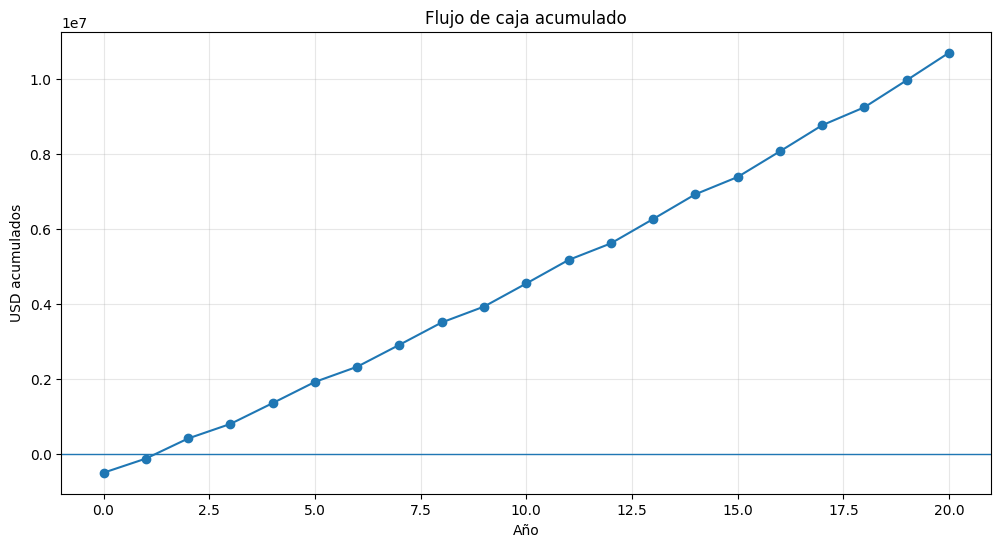

In [9]:
# Flujo de caja acumulado
plt.figure(figsize=(12, 6))
plt.plot(base_model['Year'], base_model['Cumulative Cash Flow'], marker='o')
plt.axhline(0, linewidth=1)
plt.title('Flujo de caja acumulado')
plt.xlabel('Año')
plt.ylabel('USD acumulados')
plt.grid(alpha=0.3)
plt.show()


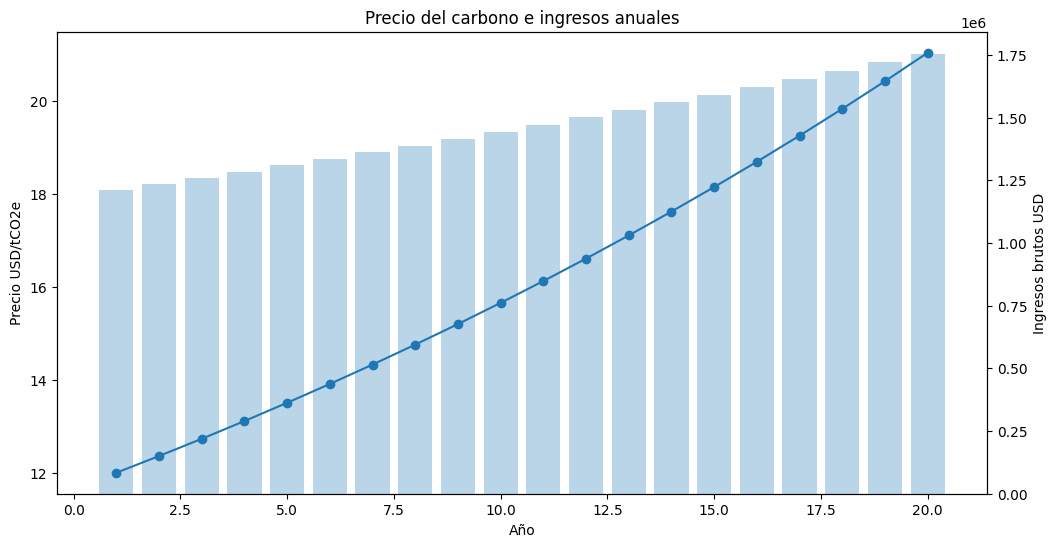

In [10]:
# Precio del carbono e ingresos
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    base_model.loc[base_model['Year'] > 0, 'Year'],
    base_model.loc[base_model['Year'] > 0, 'Carbon Price (USD/tCO2e)'],
    marker='o'
)
ax1.set_xlabel('Año')
ax1.set_ylabel('Precio USD/tCO2e')

ax2 = ax1.twinx()
ax2.bar(
    base_model.loc[base_model['Year'] > 0, 'Year'],
    base_model.loc[base_model['Year'] > 0, 'Gross Revenue'],
    alpha=0.3
)
ax2.set_ylabel('Ingresos brutos USD')

plt.title('Precio del carbono e ingresos anuales')
plt.show()


## 9. Comparación de escenarios

In [11]:
# ============================================================
# 9. ESCENARIOS CONSERVADOR, BASE Y OPTIMISTA
# ============================================================

scenarios = {
    'Conservative': {
        'carbon_price': 6.0,
        'credits_per_ha': 1.8,
        'price_growth': 0.01,
        'issuance_rate': 0.85,
        'buffer': 0.20,
        'credit_change': -0.02
    },
    'Base': {
        'carbon_price': initial_carbon_price,
        'credits_per_ha': credits_per_ha_year,
        'price_growth': annual_price_growth,
        'issuance_rate': issuance_success_rate,
        'buffer': buffer_rate,
        'credit_change': annual_credit_change
    },
    'Optimistic': {
        'carbon_price': 20.0,
        'credits_per_ha': 3.2,
        'price_growth': 0.05,
        'issuance_rate': 0.98,
        'buffer': 0.10,
        'credit_change': 0.00
    }
}

scenario_results = []
scenario_models = {}

for scenario_name, p in scenarios.items():
    model = build_carbon_model(
        years=project_years,
        area_ha=project_area_ha,
        credits_per_ha=p['credits_per_ha'],
        carbon_price=p['carbon_price'],
        price_growth=p['price_growth'],
        buffer=p['buffer'],
        issuance_rate=p['issuance_rate'],
        community_rate=community_share,
        conservation_rate=conservation_fund_share,
        initial_capex=initial_investment,
        monitoring_cost=annual_monitoring_cost,
        admin_cost=annual_admin_cost,
        verification_cost_value=verification_cost,
        verification_every=verification_frequency,
        sales_fee=sales_fee_rate,
        cost_inflation=annual_cost_inflation,
        credit_change=p['credit_change']
    )

    scenario_models[scenario_name] = model
    cf = model['Net Cash Flow'].to_numpy()

    scenario_results.append({
        'Scenario': scenario_name,
        'NPV (USD)': calculate_npv(discount_rate, cf),
        'IRR': calculate_irr(cf),
        'Payback (Years)': calculate_payback(cf),
        'Total Revenue (USD)': model['Gross Revenue'].sum(),
        'Community Benefit (USD)': model['Community Benefit'].sum(),
        'Saleable Credits': model['Saleable Credits'].sum()
    })

scenario_table = pd.DataFrame(scenario_results)
scenario_table['IRR (%)'] = scenario_table['IRR'] * 100
scenario_table.drop(columns=['IRR'], inplace=True)
scenario_table


,Scenario,NPV (USD),Payback (Years),Total Revenue (USD),Community Benefit (USD),Saleable Credits,IRR (%)
0,Conservative,"-1,342,530.10",NaN,"6,674,090.48","2,002,227.14","1,017,119.61",NaN
1,Base,"3,963,413.16",1.23,"29,342,433.42","8,802,730.03","1,838,001.85",88.45
2,Optimistic,"17,411,368.33",0.37,"93,325,348.86","27,997,604.66","2,822,400.00",280.72


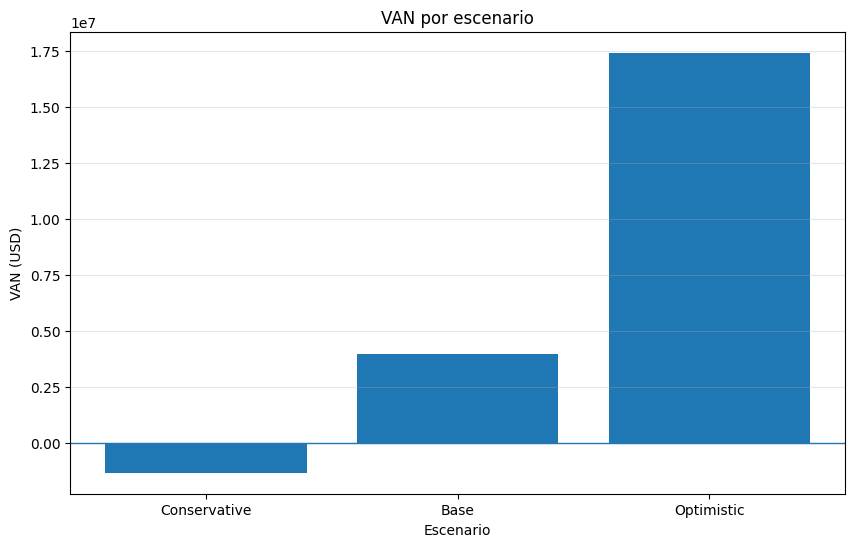

In [12]:
# Gráfico del VAN por escenario
plt.figure(figsize=(10, 6))
plt.bar(scenario_table['Scenario'], scenario_table['NPV (USD)'])
plt.axhline(0, linewidth=1)
plt.title('VAN por escenario')
plt.xlabel('Escenario')
plt.ylabel('VAN (USD)')
plt.grid(axis='y', alpha=0.3)
plt.show()


## 10. Análisis de sensibilidad

La siguiente matriz evalúa cómo cambia el VAN cuando varían el precio inicial del carbono y el volumen anual de créditos.

In [13]:
# ============================================================
# 10. SENSIBILIDAD: PRECIO VS VOLUMEN DE CRÉDITOS
# ============================================================

price_values = np.arange(5, 31, 2.5)
credit_multipliers = np.arange(0.6, 1.41, 0.1)

sensitivity_matrix = pd.DataFrame(
    index=[f'{m:.0%}' for m in credit_multipliers],
    columns=[f'USD {p:.1f}' for p in price_values],
    dtype=float
)

for m in credit_multipliers:
    for p in price_values:
        model = build_carbon_model(
            years=project_years,
            area_ha=project_area_ha,
            credits_per_ha=credits_per_ha_year * m,
            carbon_price=p,
            price_growth=annual_price_growth,
            buffer=buffer_rate,
            issuance_rate=issuance_success_rate,
            community_rate=community_share,
            conservation_rate=conservation_fund_share,
            initial_capex=initial_investment,
            monitoring_cost=annual_monitoring_cost,
            admin_cost=annual_admin_cost,
            verification_cost_value=verification_cost,
            verification_every=verification_frequency,
            sales_fee=sales_fee_rate,
            cost_inflation=annual_cost_inflation,
            credit_change=annual_credit_change
        )

        sensitivity_matrix.loc[f'{m:.0%}', f'USD {p:.1f}'] = calculate_npv(
            discount_rate,
            model['Net Cash Flow'].to_numpy()
        )

sensitivity_matrix


,USD 5.0,USD 7.5,USD 10.0,USD 12.5,USD 15.0,USD 17.5,USD 20.0,USD 22.5,USD 25.0,USD 27.5,USD 30.0
60%,"-1,333,936.18","-451,044.62","431,846.94","1,314,738.49","2,197,630.05","3,080,521.61","3,963,413.16","4,846,304.72","5,729,196.28","6,612,087.83","7,494,979.39"
70%,"-1,039,638.99","-9,598.84","1,020,441.31","2,050,481.46","3,080,521.61","4,110,561.76","5,140,601.90","6,170,642.05","7,200,682.20","8,230,722.35","9,260,762.50"
80%,"-745,341.81","431,846.94","1,609,035.68","2,786,224.42","3,963,413.16","5,140,601.90","6,317,790.65","7,494,979.39","8,672,168.13","9,849,356.87","11,026,545.62"
90%,"-451,044.62","873,292.71","2,197,630.05","3,521,967.38","4,846,304.72","6,170,642.05","7,494,979.39","8,819,316.72","10,143,654.06","11,467,991.39","12,792,328.73"
100%,"-156,747.44","1,314,738.49","2,786,224.42","4,257,710.35","5,729,196.28","7,200,682.20","8,672,168.13","10,143,654.06","11,615,139.99","13,086,625.92","14,558,111.84"
110%,"137,549.75","1,756,184.27","3,374,818.79","4,993,453.31","6,612,087.83","8,230,722.35","9,849,356.87","11,467,991.39","13,086,625.92","14,705,260.44","16,323,894.96"
120%,"431,846.94","2,197,630.05","3,963,413.16","5,729,196.28","7,494,979.39","9,260,762.50","11,026,545.62","12,792,328.73","14,558,111.84","16,323,894.96","18,089,678.07"
130%,"726,144.12","2,639,075.83","4,552,007.53","6,464,939.24","8,377,870.95","10,290,802.65","12,203,734.36","14,116,666.07","16,029,597.77","17,942,529.48","19,855,461.18"
140%,"1,020,441.31","3,080,521.61","5,140,601.90","7,200,682.20","9,260,762.50","11,320,842.80","13,380,923.10","15,441,003.40","17,501,083.70","19,561,164.00","21,621,244.30"


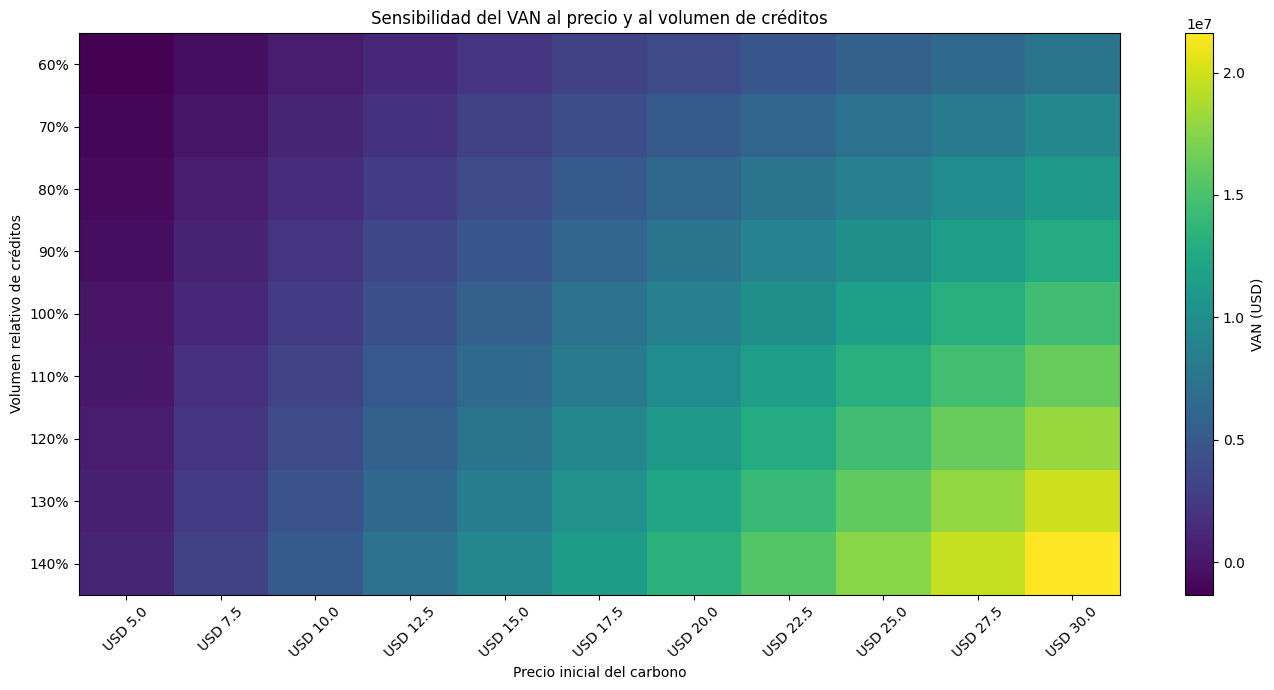

In [14]:
# Mapa de calor sin librerías adicionales
plt.figure(figsize=(14, 7))
plt.imshow(sensitivity_matrix.astype(float), aspect='auto')
plt.colorbar(label='VAN (USD)')
plt.xticks(
    ticks=np.arange(len(sensitivity_matrix.columns)),
    labels=sensitivity_matrix.columns,
    rotation=45
)
plt.yticks(
    ticks=np.arange(len(sensitivity_matrix.index)),
    labels=sensitivity_matrix.index
)
plt.title('Sensibilidad del VAN al precio y al volumen de créditos')
plt.xlabel('Precio inicial del carbono')
plt.ylabel('Volumen relativo de créditos')
plt.tight_layout()
plt.show()


## 11. Distribución de beneficios

In [15]:
# Participación acumulada de actores y costos
benefit_distribution = pd.DataFrame({
    'Category': [
        'Communities',
        'Conservation Fund',
        'Sales Fees',
        'Monitoring',
        'Administration',
        'Verification',
        'Net Project Cash Flow'
    ],
    'Amount (USD)': [
        base_model['Community Benefit'].sum(),
        base_model['Conservation Fund'].sum(),
        base_model['Sales Fees'].sum(),
        base_model['Monitoring Cost'].sum(),
        base_model['Administrative Cost'].sum(),
        base_model['Verification Cost'].sum(),
        base_model['Net Cash Flow'].sum()
    ]
})

benefit_distribution


,Category,Amount (USD)
0,Communities,"8,802,730.03"
1,Conservation Fund,"1,467,121.67"
2,Sales Fees,"1,467,121.67"
3,Monitoring,"3,065,358.91"
4,Administration,"2,043,572.61"
5,Verification,"1,297,067.23"
6,Net Project Cash Flow,"10,699,461.30"


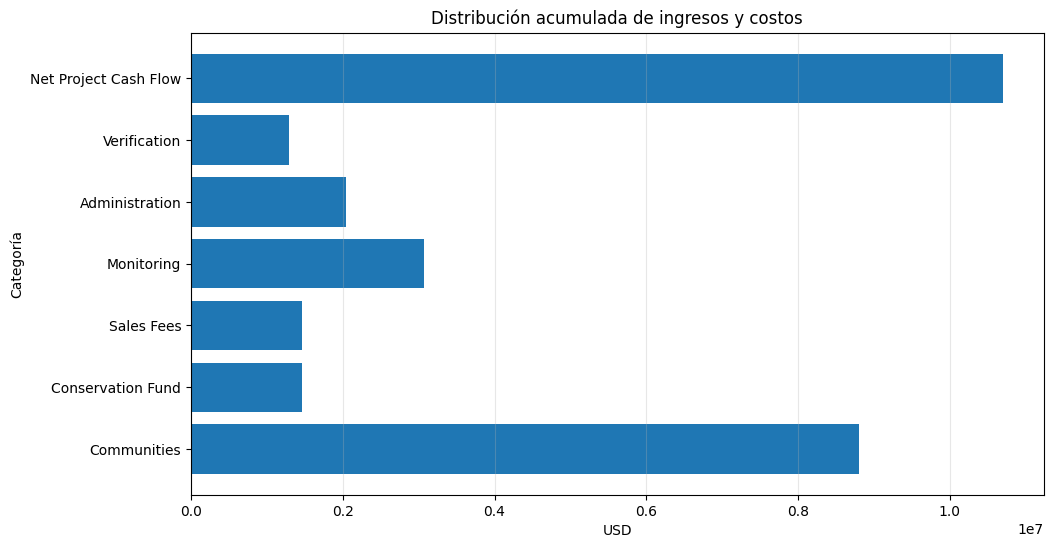

In [16]:
plt.figure(figsize=(11, 6))
plt.barh(
    benefit_distribution['Category'],
    benefit_distribution['Amount (USD)']
)
plt.title('Distribución acumulada de ingresos y costos')
plt.xlabel('USD')
plt.ylabel('Categoría')
plt.grid(axis='x', alpha=0.3)
plt.show()


## 12. Exportación de resultados

Los archivos se guardarán en una carpeta llamada `carbon_model_outputs`.

In [17]:
# ============================================================
# 12. EXPORTACIÓN DE RESULTADOS
# ============================================================

output_dir = Path('/content/carbon_model_outputs')
output_dir.mkdir(parents=True, exist_ok=True)

base_model.to_csv(output_dir / 'base_case_cash_flow.csv', index=False)
summary.to_csv(output_dir / 'financial_summary.csv', index=False)
scenario_table.to_csv(output_dir / 'scenario_comparison.csv', index=False)
sensitivity_matrix.to_csv(output_dir / 'npv_sensitivity_matrix.csv')
benefit_distribution.to_csv(output_dir / 'benefit_distribution.csv', index=False)

print('Archivos creados:')
for file in output_dir.iterdir():
    print('-', file.name)


Archivos creados:
- benefit_distribution.csv
- financial_summary.csv
- scenario_comparison.csv
- base_case_cash_flow.csv
- npv_sensitivity_matrix.csv


In [18]:
# Descargar todos los resultados como ZIP desde Google Colab
import shutil
from google.colab import files

zip_path = shutil.make_archive(
    '/content/carbon_model_outputs',
    'zip',
    output_dir
)

files.download(zip_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Interpretación automática básica

In [19]:
# ============================================================
# 13. INTERPRETACIÓN AUTOMÁTICA
# ============================================================

print('INTERPRETACIÓN DEL CASO BASE')
print('-' * 50)

if npv_value > 0:
    print('• El VAN es positivo: el proyecto crea valor bajo los supuestos utilizados.')
else:
    print('• El VAN es negativo: el proyecto no cubre la rentabilidad exigida.')

if not np.isnan(irr_value):
    if irr_value > discount_rate:
        print('• La TIR supera la tasa de descuento.')
    else:
        print('• La TIR está por debajo de la tasa de descuento.')
else:
    print('• No fue posible calcular una TIR económicamente interpretable.')

if not np.isnan(payback_value):
    print(f'• La inversión inicial se recupera aproximadamente en {payback_value:.2f} años.')
else:
    print('• La inversión no se recupera dentro del horizonte analizado.')

community_pct_of_revenue = total_community_benefit / total_revenue
print(f'• Las comunidades reciben aproximadamente {community_pct_of_revenue:.1%} de los ingresos brutos.')
print(f'• El costo promedio estimado es USD {cost_per_credit:,.2f} por crédito comercializable.')


INTERPRETACIÓN DEL CASO BASE
--------------------------------------------------
• El VAN es positivo: el proyecto crea valor bajo los supuestos utilizados.
• La TIR supera la tasa de descuento.
• La inversión inicial se recupera aproximadamente en 1.23 años.
• Las comunidades reciben aproximadamente 30.0% de los ingresos brutos.
• El costo promedio estimado es USD 10.14 por crédito comercializable.


## Próximas mejoras sugeridas

Para convertir este notebook en un proyecto más avanzado de GitHub puedes añadir:

1. datos espaciales con GeoPandas;
2. polígonos de comunidades o concesiones;
3. escenarios probabilísticos con simulación Monte Carlo;
4. estimaciones de riesgo de incendios y permanencia;
5. comparación entre metodologías REDD+, IFM y ARR;
6. dashboard interactivo en Streamlit;
7. documentación bilingüe español-inglés;
8. pruebas unitarias para las funciones financieras.
